[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hramdasan/elixir_summerschool_26/blob/main/notebooks/3-convolutional-neural-networks.ipynb)

# 3 Convolutional neural networks

Start with images to build intuition, then transfer the same idea to DNA:

1. Slide a hand-written filter over a tiny image.
2. Train a 2D CNN to distinguish round and elongated **synthetic nuclei**.
3. Inspect learned filters, feature maps, prediction overlays and held-out predictions.
4. Apply a 1D CNN to detect a motif in **synthetic DNA sequences**.

Both datasets are generated here and run on CPU without a download. Their labels describe generated shape or exact motif presence, not measured cell phenotypes or promoter activity.

## Before you start: Colab setup

In Colab, select **File → Save a copy in Drive** to keep your answers. Run the setup cell below first, then run the remaining cells from top to bottom with **Shift + Enter**. This is provided setup code; you do not need to modify it for the exercises.

The cell installs the packages needed by this notebook. If Colab asks you to restart the session after installation, restart it and run from the setup cell again. A standard CPU runtime is sufficient.

In local Jupyter, this cell does not install anything. Follow the [README installation instructions](https://github.com/hramdasan/elixir_summerschool_26#run-locally) instead.

The setup also enables interactive widgets in Colab. Static plots remain available if your notebook viewer cannot display the controls.

In [ ]:
# Provided setup: run once before the exercises in a fresh Colab session.
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    %pip install -q "torch>=2.6,<3" "numpy>=2,<3" "pandas>=2.2,<3" "scikit-learn>=1.6,<2" "matplotlib>=3.9,<4" "ipywidgets>=8,<9"
    from google.colab import output
    output.enable_custom_widget_manager()
    print("Setup complete. Continue with the cells below.")
else:
    print("Local Jupyter: use the README installation instructions, then continue below.")

In [1]:
import random
import numpy as np
import torch

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.set_num_threads(2)

seed_everything(42)

## 3.1 A filter is a small pattern detector
Start with a tiny artificial image containing a vertical boundary between dark and bright regions. A 3 × 3 filter examines neighboring pixels with the same weights wherever it moves. This **parameter sharing** is the key idea of convolution.

The filter here is hand-written, so we know what it detects. A CNN learns filter weights from training examples. PyTorch's operation is technically cross-correlation (the kernel is not flipped), conventionally called convolution in neural networks.

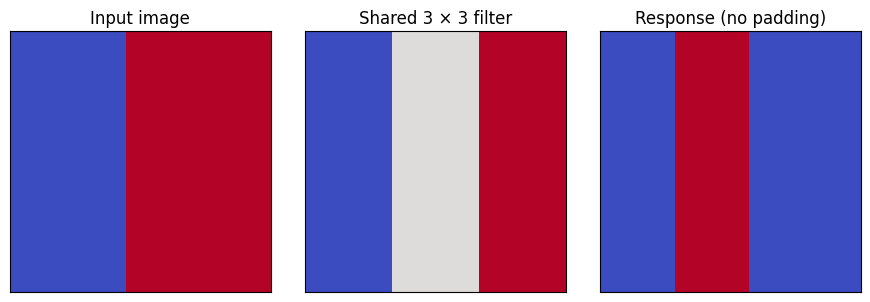

In [2]:
import numpy as np, pandas as pd, torch
from torch import nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
image = torch.zeros(1, 1, 9, 9)
image[:, :, :, 4:] = 1
filter_2d = torch.tensor([[-1., 0., 1.], [-1., 0., 1.], [-1., 0., 1.]]).reshape(1, 1, 3, 3)
response = F.conv2d(image, filter_2d)
fig, axes = plt.subplots(1, 3, figsize=(9, 3))
for ax, values, title in zip(axes, [image[0, 0], filter_2d[0, 0], response[0, 0]],
                              ["Input image", "Shared 3 × 3 filter", "Response (no padding)"]):
    ax.imshow(values, cmap="coolwarm")
    ax.set_title(title)
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

*Assignment: Move the pattern*

If the vertical boundary moves two pixels right, what happens to the filter response? How might this help with microscopy images?

*Write your answer here.*

## 3.2 From pixels to a biological question

Imagine cropped fluorescence images, each containing one nucleus. Could a model distinguish **round** from **elongated** nuclei? First look at the images; then let the model learn useful filters instead of specifying them ourselves.

We generate **synthetic microscopy-like images**, not experimental measurements. The label describes the shape we draw; it does not indicate a cell type, treatment response or disease. This small exercise runs on CPU without downloading a dataset.

The two classes share the same distributions of size, brightness, background and position. Elongated nuclei have approximately the same area as round ones. Orientation varies too, so “elongated” does not just mean “horizontal”. Noise and soft boundaries make the images less like perfect binary masks, but they still omit much of the complexity of real microscopy.

Training image shape: (1000, 1, 32, 32)
Training labels: [500 500]


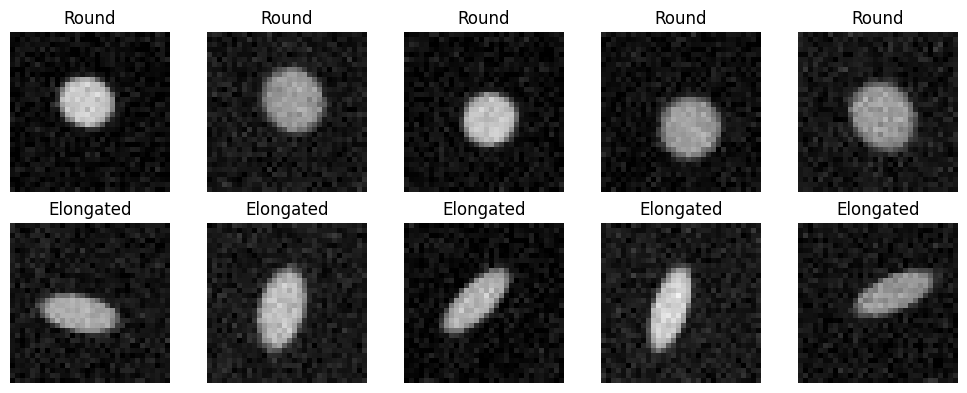

In [3]:
def nucleus_images(n=1000, size=32, seed=20):
    """Synthetic shape labels: 0 = round, 1 = elongated; not real microscopy."""
    rng = np.random.default_rng(seed)
    labels = (np.arange(n) % 2).astype(np.float32)
    rng.shuffle(labels)
    yy, xx = np.mgrid[:size, :size]
    images = np.empty((n, 1, size, size), dtype=np.float32)
    for i, label in enumerate(labels):
        center_x, center_y = rng.uniform(13, 19, size=2)
        angle = rng.uniform(0, np.pi)
        radius = rng.uniform(5.0, 6.5)
        aspect = rng.uniform(1.8, 2.5) if label else rng.uniform(1.0, 1.2)
        # a * b = radius ** 2: changing elongation preserves ellipse area.
        a, b = radius * np.sqrt(aspect), radius / np.sqrt(aspect)
        dx, dy = xx - center_x, yy - center_y
        u = np.cos(angle) * dx + np.sin(angle) * dy
        v = -np.sin(angle) * dx + np.cos(angle) * dy
        distance = (u / a) ** 2 + (v / b) ** 2
        soft_nucleus = 1 / (1 + np.exp(np.clip(7 * (distance - 1), -60, 60)))
        background = rng.uniform(0.04, 0.12)
        brightness = rng.uniform(0.5, 0.85)
        noise = rng.normal(0, 0.045, size=(size, size))
        images[i, 0] = np.clip(background + brightness * soft_nucleus + noise, 0, 1)
    return images, labels

# Independent simulated examples for each split. Use validation during development.
image_x_train, image_y_train = nucleus_images(1000, seed=20)
image_x_val, image_y_val = nucleus_images(200, seed=21)
image_x_test, image_y_test = nucleus_images(200, seed=22)
shape_names = np.array(["Round", "Elongated"])
print("Training image shape:", image_x_train.shape)
print("Training labels:", np.bincount(image_y_train.astype(int)))

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for label, row in enumerate(axes):
    examples = np.flatnonzero(image_y_train == label)[:5]
    for ax, index in zip(row, examples):
        ax.imshow(image_x_train[index, 0], cmap="gray", vmin=0, vmax=1)
        ax.set_title(shape_names[label])
        ax.axis("off")
plt.tight_layout()
plt.show()

*Assignment: Inspect the data before fitting*

Which visual feature separates these labels? Why might a classifier based only on average brightness fail? For real microscopy, could a model accidentally learn the microscope or staining batch instead of nuclear shape?

*Write your answer here.*

## 3.3 Build an image CNN: local patterns become a prediction

PyTorch expects images as **(examples, channels, height, width)**. Here there is one grayscale fluorescence channel; multiple measured fluorescence channels could be stacked along that axis.

- `Conv2d` learns small filters that slide across height and width. Each filter produces a **feature map**: its response at every location.
- `ReLU` retains positive responses. `MaxPool2d(2)` keeps the largest response in each 2 × 2 window, reducing spatial resolution.
- A second convolution combines nearby first-layer responses. Flattening and a small classifier turn these maps into one logit for “elongated”.

Follow the shapes: `(batch, 1, 32, 32)` → convolution → `(batch, 8, 32, 32)` → pooling → `(batch, 8, 16, 16)` → convolution → `(batch, 16, 16, 16)` → pooling → `(batch, 16, 8, 8)` → flatten → `(batch, 1024)` → classifier → `(batch, 1)`.

Padding of 1 preserves height and width for a 3 × 3 convolution. Pooling reduces detail; it does not guarantee invariance to position or rotation. We include varied positions and orientations in the training images.

In [4]:
class NucleusCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 8, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 8 * 8, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
        )

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        return self.classifier(x)

seed_everything(42)
image_model = NucleusCNN()
print("Parameters:", sum(p.numel() for p in image_model.parameters()))
print("Output shape:", image_model(torch.tensor(image_x_train[:3])).shape)

Parameters: 17665


Output shape: torch.Size([3, 1])


*Assignment: Channels are not classes*

Our input has one channel, but the first convolution outputs eight channels. What do those eight channels represent? What shape would the input have for a batch of 16 images with three fluorescence channels, each 32 × 32 pixels?

*Write your answer here.*

## 3.4 Train the filters from examples

The training loop is the same binary classification workflow as before: one logit per image, `BCEWithLogitsLoss`, Adam and a separate validation pass. The loss includes the sigmoid, so the model should return logits. We apply sigmoid when displaying probabilities.

The helpers below work for both images and DNA. We retain the weights with the lowest validation loss. Leave the test images aside until section 3.6.

Each epoch has two separate loops. **Training** clears old gradients, makes predictions, computes the loss and gradients, and updates the weights. **Validation** makes predictions and measures loss without updating weights.

`model.train()` enables training behavior such as dropout; `model.eval()` switches to evaluation behavior. `torch.no_grad()` separately turns off gradient recording during validation. Backpropagation (`loss.backward()`) computes gradients; the optimizer (`optimizer.step()`) uses them to update parameters.

In [5]:
from torch.utils.data import DataLoader, TensorDataset
from copy import deepcopy
from torch import nn
import pandas as pd
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score
import matplotlib.pyplot as plt

def loader(x, y, batch_size=32, shuffle=False, seed=42):
    return DataLoader(
        TensorDataset(torch.as_tensor(x, dtype=torch.float32), torch.as_tensor(y, dtype=torch.float32)),
        batch_size=batch_size, shuffle=shuffle,
        generator=torch.Generator().manual_seed(seed), num_workers=0,
    )

def fit_binary(model, train_loader, val_loader, epochs=30, lr=0.001, weight_decay=0.0):
    """Train on CPU, restore the best validation weights, and return loss history.

    Models return ONE LOGIT per example. The loss includes the sigmoid.
    Loss means are weighted by sample count, including the last short batch.
    """
    loss_fn = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    best_loss = float("inf")
    best_weights = deepcopy(model.state_dict())
    history = []

    for epoch in range(epochs):
        # Training: make predictions, calculate loss, and update the weights.
        model.train()
        train_total_loss = 0.0
        train_count = 0
        for x, y in train_loader:
            optimizer.zero_grad()
            logits = model(x).squeeze(-1)
            loss = loss_fn(logits, y)
            loss.backward()
            optimizer.step()
            train_total_loss += loss.item() * len(y)
            train_count += len(y)
        train_loss = train_total_loss / train_count

        # Validation: measure loss without changing the weights.
        model.eval()
        val_total_loss = 0.0
        val_count = 0
        with torch.no_grad():
            for x, y in val_loader:
                logits = model(x).squeeze(-1)
                loss = loss_fn(logits, y)
                val_total_loss += loss.item() * len(y)
                val_count += len(y)
        val_loss = val_total_loss / val_count

        # Keep a copy of the weights with the lowest validation loss.
        if val_loss < best_loss:
            best_loss = val_loss
            best_weights = deepcopy(model.state_dict())
        history.append({"epoch": epoch + 1, "train_loss": train_loss, "val_loss": val_loss})

    model.load_state_dict(best_weights)
    model.eval()
    return pd.DataFrame(history)

@torch.no_grad()
def probabilities(model, x):
    model.eval()
    return torch.sigmoid(model(torch.as_tensor(x, dtype=torch.float32)).squeeze(-1)).numpy()

def binary_scores(y, probability):
    predicted = np.asarray(probability) >= 0.5
    return {
        "accuracy": accuracy_score(y, predicted),
        "balanced_accuracy": balanced_accuracy_score(y, predicted),
        "ROC_AUC": roc_auc_score(y, probability),
    }

def plot_history(history, title="Training and validation loss"):
    ax = history.plot(x="epoch", y=["train_loss", "val_loss"], figsize=(6, 3.5))
    ax.set(xlabel="Epoch (one pass through training data)", ylabel="Binary cross-entropy", title=title)
    plt.tight_layout()
    plt.show()

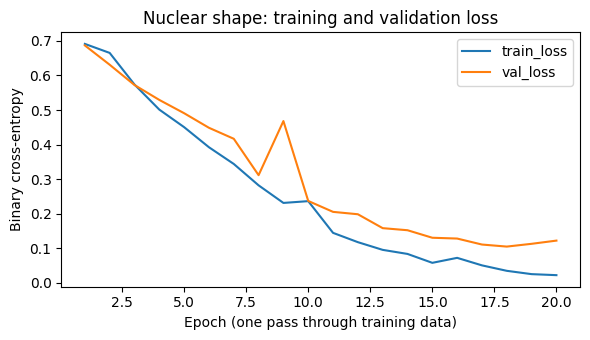

accuracy             0.9650
balanced_accuracy    0.9650
ROC_AUC              0.9925
Name: Image validation, dtype: float64

In [6]:
image_history = fit_binary(
    image_model,
    loader(image_x_train, image_y_train, batch_size=64, shuffle=True),
    loader(image_x_val, image_y_val, batch_size=64),
    epochs=20, lr=0.003,
)
plot_history(image_history, title="Nuclear shape: training and validation loss")
display(pd.Series(binary_scores(image_y_val, probabilities(image_model, image_x_val)),
                  name="Image validation"))

## 3.5 Look inside: learned filters and feature maps

The introductory edge filter was chosen by us. These eight filters were updated by the loss during training. Below, the same learned filters are applied to a round and an elongated validation example.

Compare the input with each response map. Some filters may respond to boundaries or bright regions; others may be hard to interpret or inactive. A first-layer feature map is **not** a segmentation mask or an explanation of the final prediction. Later layers combine these responses.

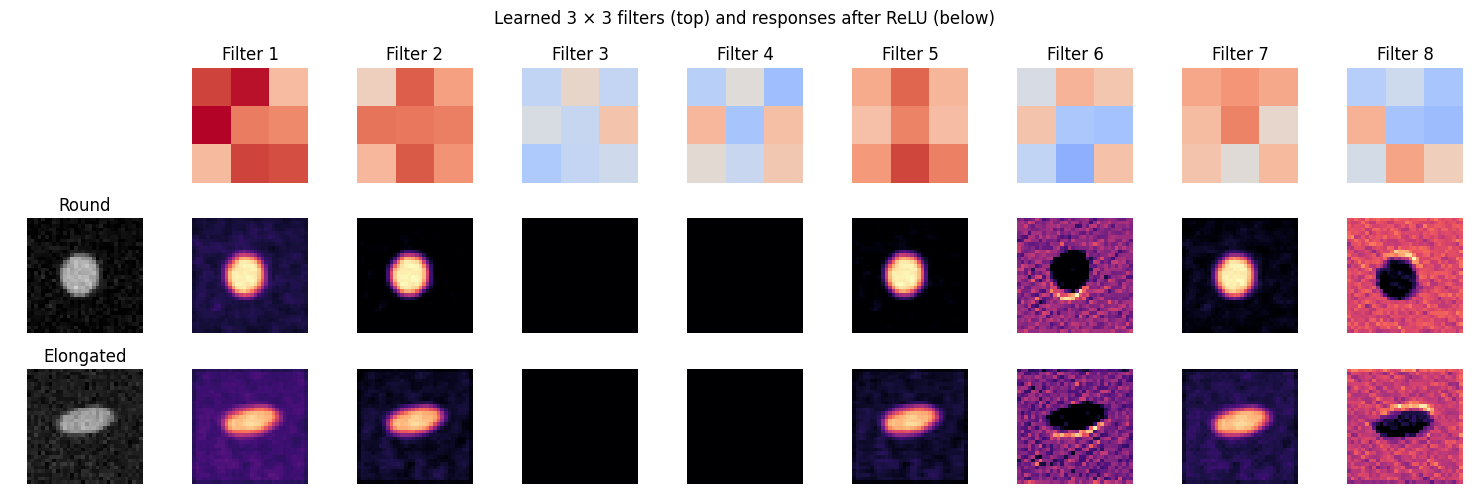

In [7]:
image_model.eval()
example_indices = [np.flatnonzero(image_y_val == label)[0] for label in (0, 1)]
with torch.no_grad():
    learned_filters = image_model.conv1.weight[:, 0].detach().numpy()
    feature_maps = torch.relu(image_model.conv1(
        torch.tensor(image_x_val[example_indices])
    )).numpy()

fig, axes = plt.subplots(3, 9, figsize=(15, 5))
axes[0, 0].axis("off")
filter_limit = max(float(np.abs(learned_filters).max()), 1e-6)
for j in range(8):
    axes[0, j + 1].imshow(learned_filters[j], cmap="coolwarm",
                          vmin=-filter_limit, vmax=filter_limit)
    axes[0, j + 1].set_title(f"Filter {j + 1}")
    axes[0, j + 1].axis("off")
for row, index in enumerate(example_indices, start=1):
    axes[row, 0].imshow(image_x_val[index, 0], cmap="gray", vmin=0, vmax=1)
    axes[row, 0].set_title(shape_names[int(image_y_val[index])])
    axes[row, 0].axis("off")
    for j in range(8):
        # Same response scale for both examples within each feature-map column.
        response_limit = max(float(feature_maps[:, j].max()), 1e-6)
        axes[row, j + 1].imshow(feature_maps[row - 1, j], cmap="magma",
                                vmin=0, vmax=response_limit)
        axes[row, j + 1].axis("off")
fig.suptitle("Learned 3 × 3 filters (top) and responses after ReLU (below)")
plt.tight_layout()
plt.show()

*Assignment: What does a filter respond to?*

Pick a feature map that responds near a nuclear boundary. Does it respond everywhere along that boundary or more strongly on some sides? Why does seeing this response not prove that the final classifier uses nuclear shape?

*Write your answer here.*

### 3.5.1 Which image regions affect the prediction?

The feature maps above show what individual filters respond to. Now ask a question about the **final prediction**: if we cover part of this nucleus, how does the model's score change?

**Occlusion sensitivity** slides a small square over the image, replaces that region with a background value, and reruns the trained model. This approach was used by [Zeiler and Fergus (2014), section 4.2](https://cs.nyu.edu/~fergus/papers/zeilerECCV2014.pdf).

For a chosen class, calculate **probability before covering − probability after covering**:

- **Red / positive:** covering this region lowers the chosen class probability.
- **Blue / negative:** covering this region raises the chosen class probability.
- **Near zero:** covering this region changes that probability little.

For example, a change from 0.90 to 0.60 is a drop of **30 percentage points**. The target stays fixed to the original predicted class unless you explicitly select Round or Elongated, even if covering a patch changes the prediction.

The overlay maps these changes back onto the original image. Overlapping patch scores are averaged at each covered pixel; this is a regional sensitivity map, not a measurement of individual pixel contributions. Every figure uses the same −100 to +100 percentage-point color scale.

We use **validation images** for this exploration and leave test evaluation in section 3.6. The model is already trained; these visualizations do not update its weights.

In [8]:
def occlusion_sensitivity(model, image, target="predicted", patch_size=8,
                          stride=4, fill="background"):
    """Cover patches of one (1, height, width) image; keep the target fixed."""
    image = np.asarray(image, dtype=np.float32)
    _, height, width = image.shape
    if not 1 <= stride <= patch_size <= min(height, width):
        raise ValueError("Require 1 <= stride <= patch_size <= image size.")
    p_elongated = float(probabilities(model, image[None])[0])
    if target == "predicted":
        target_class = int(p_elongated >= 0.5)
    elif target in (0, 1):
        target_class = int(target)
    else:
        raise ValueError("Choose 'predicted', 0 (Round) or 1 (Elongated).")
    original_probability = p_elongated if target_class else 1 - p_elongated

    # In this simulator the image border is background. This assumption may
    # fail for real crops where a nucleus touches an edge.
    border = np.concatenate((image[0, 0, :], image[0, -1, :],
                             image[0, 1:-1, 0], image[0, 1:-1, -1]))
    if fill == "background":
        fill_value = float(np.median(border))
    elif fill == "black":
        fill_value = 0.0
    else:
        raise ValueError("Choose 'background' or 'black'.")

    # Include the final position even when stride does not divide the span.
    rows = sorted(set(range(0, height - patch_size + 1, stride)) | {height - patch_size})
    columns = sorted(set(range(0, width - patch_size + 1, stride)) | {width - patch_size})
    positions = [(row, col) for row in rows for col in columns]
    covered_images = np.repeat(image[None], len(positions), axis=0)
    for i, (row, col) in enumerate(positions):
        covered_images[i, :, row:row + patch_size, col:col + patch_size] = fill_value
    # Small batches keep this CPU-friendly even for many patch positions.
    covered_p = np.concatenate([probabilities(model, covered_images[start:start + 64])
                                for start in range(0, len(positions), 64)])
    if target_class == 0:
        covered_p = 1 - covered_p
    changes = original_probability - covered_p
    total = np.zeros((height, width), dtype=np.float32)
    count = np.zeros((height, width), dtype=np.float32)
    for change, (row, col) in zip(changes, positions):
        total[row:row + patch_size, col:col + patch_size] += change
        count[row:row + patch_size, col:col + patch_size] += 1
    return {"map": total / count, "changes": changes, "positions": positions,
            "covered_probabilities": covered_p, "target_class": target_class,
            "original_probability": original_probability,
            "p_elongated": p_elongated, "fill_value": fill_value}


def plot_occlusion(index=0, patch_size=8, target="predicted", opacity=0.65,
                   fill="background"):
    from matplotlib.patches import Rectangle

    original = image_x_val[index]
    result = occlusion_sensitivity(image_model, original, target=target,
                                   patch_size=patch_size, fill=fill)
    target_name = shape_names[result["target_class"]]
    predicted_name = shape_names[int(result["p_elongated"] >= 0.5)]
    # Show the actual intervention with the largest absolute score change.
    strongest = int(np.abs(result["changes"]).argmax())
    row, col = result["positions"][strongest]
    covered = original.copy()
    covered[:, row:row + patch_size, col:col + patch_size] = result["fill_value"]
    effect = 100 * result["map"]
    fig, axes = plt.subplots(1, 4, figsize=(14, 4), layout="constrained")
    axes[0].imshow(original[0], cmap="gray", vmin=0, vmax=1)
    axes[0].set_title(f"Original\np({target_name})={result['original_probability']:.2f}")
    heatmap = axes[1].imshow(effect, cmap="RdBu_r", vmin=-100, vmax=100,
                             interpolation="nearest")
    axes[1].set_title("Covering sensitivity\nRed: probability drops")
    axes[2].imshow(original[0], cmap="gray", vmin=0, vmax=1)
    # Leave regions with no effect transparent so the image remains visible.
    alpha = opacity * np.minimum(np.abs(effect) / 20, 1)
    axes[2].imshow(effect, cmap="RdBu_r", vmin=-100, vmax=100,
                   alpha=alpha, interpolation="nearest")
    axes[2].set_title("Overlay on original\nBox: patch shown at right")
    axes[3].imshow(covered[0], cmap="gray", vmin=0, vmax=1)
    after = float(result["covered_probabilities"][strongest])
    delta = float(result["changes"][strongest]) * 100
    axes[3].set_title(f"Covered {patch_size} × {patch_size} patch\n"
                      f"p({target_name})={after:.2f}; drop={delta:+.1f} pp")
    for ax in axes[2:]:
        ax.add_patch(Rectangle((col - 0.5, row - 0.5), patch_size, patch_size,
                               fill=False, edgecolor="#F0E442", linewidth=1.5))
    for ax in axes:
        ax.axis("off")
    fig.colorbar(heatmap, ax=axes[1:3], shrink=0.72,
                 label="Probability before − after (percentage points)")
    fig.suptitle(f"Validation image {index} | true: {shape_names[int(image_y_val[index])]} | "
                  f"predicted: {predicted_name} | explaining: {target_name}\n"
                  f"Fill: {fill} ({result['fill_value']:.2f}); overlapping patches averaged")
    plt.show()

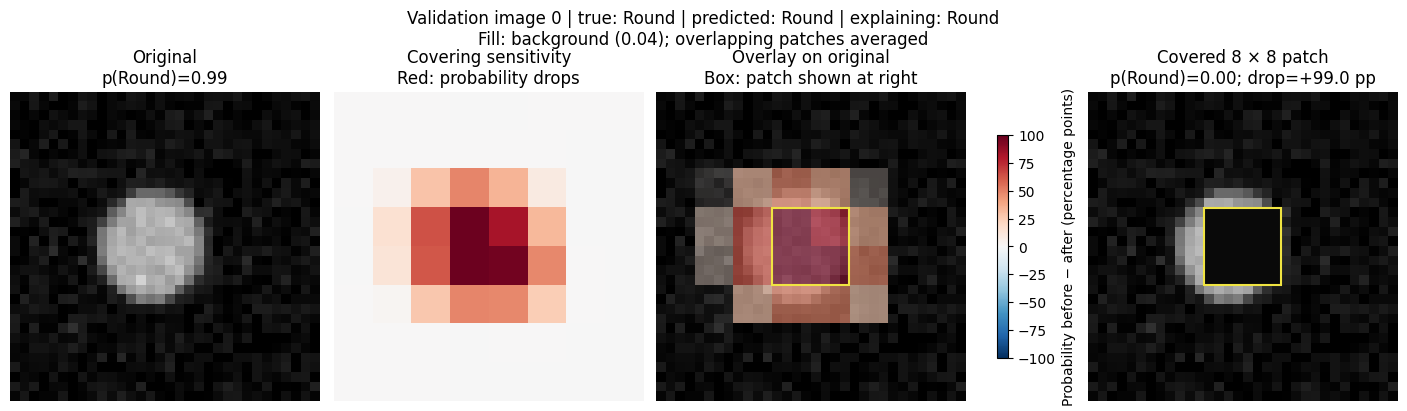

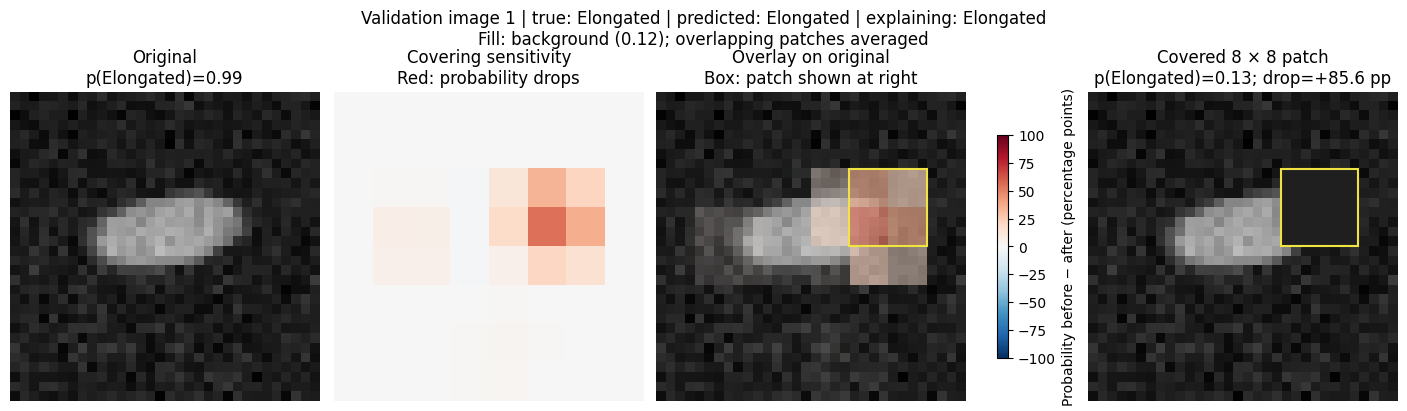

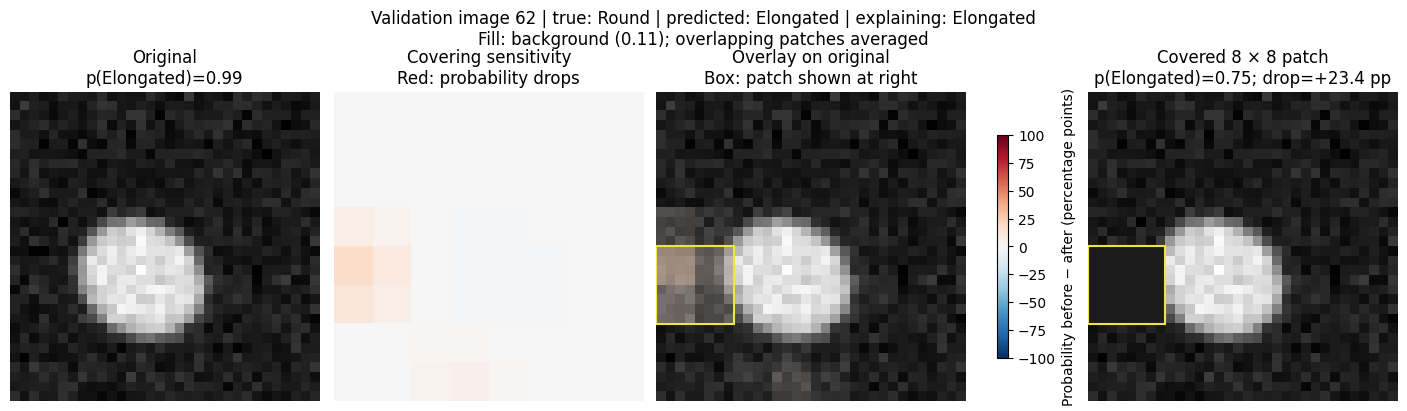

In [9]:
# First example of each shape; also inspect a mistake if one exists.
overlay_examples = [int(np.flatnonzero(image_y_val == label)[0]) for label in (0, 1)]
overlay_val_probability = probabilities(image_model, image_x_val)
overlay_errors = np.flatnonzero((overlay_val_probability >= 0.5) != image_y_val)
if len(overlay_errors):
    overlay_examples.append(int(overlay_errors[0]))
for example_index in dict.fromkeys(overlay_examples):
    plot_occlusion(index=example_index, patch_size=8)

# Without widgets, edit a call such as:
# plot_occlusion(index=0, patch_size=4, target=1, opacity=0.65, fill="background")

### 3.5.2 Explore the overlay

Use the controls to select a validation image, the class to explain, the covering patch size, its replacement value and the overlay opacity. Image labels include the true and predicted shape so you can deliberately inspect mistakes. Each change runs a small batch of covered images through the **same trained model**; it does not retrain it.

As with the attention visualizations in notebook 5, the static figures above work without widgets. If controls are unavailable, edit the arguments to `plot_occlusion` directly. The heatmap's colors use the labeled score scale; overlay opacity only changes visibility, with near-zero effects left transparent.

In [10]:
try:
    import ipywidgets as widgets
except ImportError:
    print("Widgets are unavailable. Edit the plot_occlusion(...) call above.")
else:
    image_options = [
        (f"{i}: true {shape_names[int(label)]}, pred {shape_names[int(p >= 0.5)]}"
         + (" (error)" if int(p >= 0.5) != int(label) else ""), i)
        for i, (label, p) in enumerate(zip(image_y_val, overlay_val_probability))
    ]
    overlay_image_control = widgets.Dropdown(options=image_options,
        value=overlay_examples[0], description="Image:", layout=widgets.Layout(width="420px"))
    overlay_target_control = widgets.Dropdown(
        options=[("Predicted class", "predicted"), ("Round", 0), ("Elongated", 1)],
        value="predicted", description="Explain:")
    overlay_patch_control = widgets.Dropdown(options=[4, 8, 12], value=8, description="Patch:")
    overlay_fill_control = widgets.Dropdown(
        options=[("Border background", "background"), ("Black", "black")],
        value="background", description="Cover with:")
    overlay_opacity_control = widgets.FloatSlider(value=0.65, min=0, max=1, step=0.05,
        description="Opacity:", continuous_update=False)
    overlay_view = widgets.interactive_output(plot_occlusion,
        {"index": overlay_image_control, "target": overlay_target_control,
         "patch_size": overlay_patch_control, "fill": overlay_fill_control,
         "opacity": overlay_opacity_control})
    display(widgets.VBox([
        widgets.HBox([overlay_image_control, overlay_target_control]),
        widgets.HBox([overlay_patch_control, overlay_fill_control, overlay_opacity_control]),
    ]), overlay_view)

Output()

### 3.5.3 What does the colored region mean biologically?

This CNN has no attention layer. The overlay is a **post-training sensitivity experiment**, not attention weights or a nucleus segmentation. It shows changes in this model's score when we alter this input. Covering creates artificial edges and unfamiliar shapes, so an effect can reflect the replacement artifact as well as the removed information.

A hot region does not establish a biological mechanism or identify a subcellular structure. Patch size and replacement intensity can change the map; a flat map can also occur when probabilities are saturated or evidence is redundant. The regional values are not additive contributions and need not sum to the prediction. Use them to generate questions and investigate shortcuts.

*Assignment: Explain a prediction, then challenge the explanation*

1. Compare a round and an elongated nucleus. Do the strongest changes overlap the nucleus, its boundary or the background? Check the covered image and the probability change.
2. Keep the image fixed and switch the explained class. Why do red and blue reverse in this binary classifier?
3. Compare patch sizes 4 and 12, then change the replacement from background to black. Which conclusions survive these changes?
4. Inspect an error. Does a plausible-looking overlay make the prediction correct, or prove that the model learned biological morphology?

*Write your answer here.*

## 3.6 Evaluate the image task and its limits

Compare the CNN against logistic regression using only each image's mean and standard deviation of intensity. This deliberately simple **intensity baseline** ignores spatial arrangement. It checks whether global brightness or contrast already carries label information; it is not a strong morphology baseline.

The baseline has a fixed configuration and is fitted on training images. Evaluate both methods on the held-out test set now. This tests new draws from our simulator, not generalization to real nuclei. In an experimental study, a useful next comparison would use measured shape features such as eccentricity.

,accuracy,balanced_accuracy,ROC_AUC
Intensity baseline,0.530,0.530,0.5110
Image CNN,0.975,0.975,0.9972


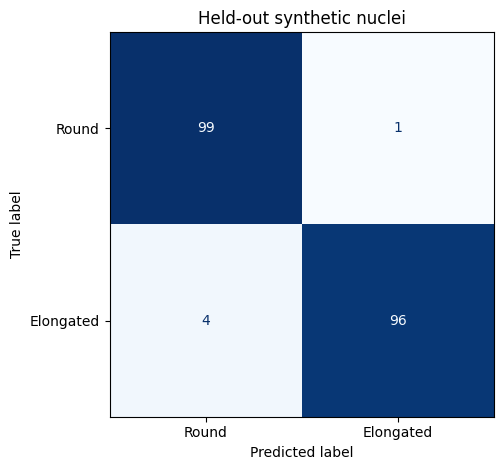

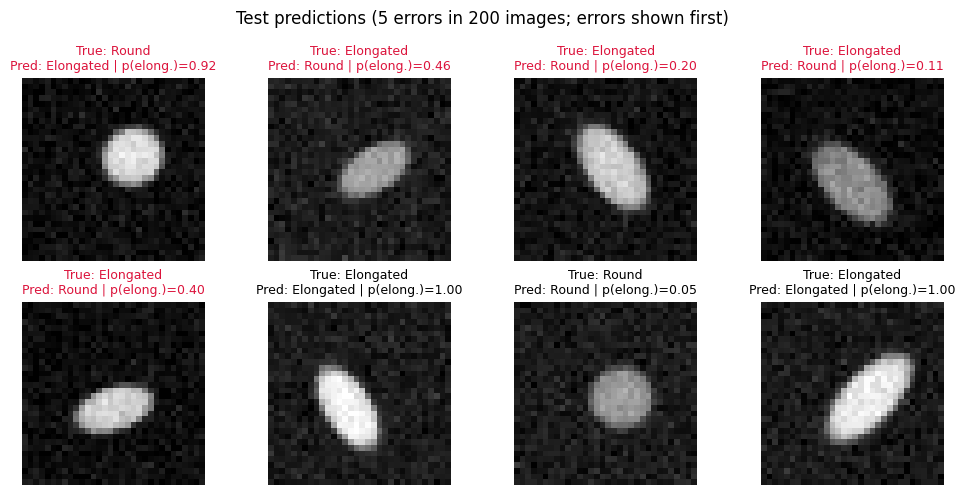

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import ConfusionMatrixDisplay

def intensity_features(images):
    return np.column_stack((images.mean(axis=(1, 2, 3)), images.std(axis=(1, 2, 3))))

image_baseline = make_pipeline(StandardScaler(), LogisticRegression(
    C=1.0, max_iter=1000, random_state=42))
image_baseline.fit(intensity_features(image_x_train), image_y_train)
image_test_probability = probabilities(image_model, image_x_test)
image_results = {
    "Intensity baseline": binary_scores(image_y_test, image_baseline.predict_proba(
        intensity_features(image_x_test))[:, 1]),
    "Image CNN": binary_scores(image_y_test, image_test_probability),
}
display(pd.DataFrame(image_results).T)
ConfusionMatrixDisplay.from_predictions(
    image_y_test.astype(int), (image_test_probability >= 0.5).astype(int),
    labels=[0, 1], display_labels=shape_names, cmap="Blues", colorbar=False,
)
plt.title("Held-out synthetic nuclei")
plt.tight_layout()
plt.show()

# Show errors first, then other examples if fewer than eight were misclassified.
wrong = np.flatnonzero((image_test_probability >= 0.5) != image_y_test)
correct = np.flatnonzero((image_test_probability >= 0.5) == image_y_test)
shown = np.concatenate((wrong, correct))[:8]
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for ax, index in zip(axes.flat, shown):
    p = image_test_probability[index]
    predicted = int(p >= 0.5)
    ax.imshow(image_x_test[index, 0], cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"True: {shape_names[int(image_y_test[index])]}\n"
                 f"Pred: {shape_names[predicted]} | p(elong.)={p:.2f}",
                 fontsize=9, color="crimson" if index in wrong else "black")
    ax.axis("off")
fig.suptitle(f"Test predictions ({len(wrong)} errors in {len(image_y_test)} images; errors shown first)")
plt.tight_layout()
plt.show()

*Assignment: Would this work in the lab?*

You now have many nuclear crops from each of six microscopy experiments. Why could randomly splitting individual crops overestimate performance? What should you group together when splitting, and what does high accuracy on these synthetic images actually establish?

*Write your answer here.*

## 3.7 From images to DNA: the same local-pattern idea

A filter can scan two spatial axes in an image or one positional axis in a sequence. For images, it might respond to a local boundary; for DNA, it can learn a local combination of bases. **The shared idea is to reuse the same learned weights at every location.**

| | Nuclear images | DNA sequences |
|---|---|---|
| Input shape | `(batch, 1, 32, 32)` | `(batch, 4, 48)` |
| Input channels | Fluorescence intensity | One-hot A, C, G, T |
| Filter moves along | Height and width | Sequence position |
| PyTorch layer | `Conv2d` | `Conv1d` |
| Toy question | Round or elongated? | Is `TATAAA` present? |

The four DNA channels are categories at each position, not a second spatial axis. We will now train a smaller sequence CNN with the same training helpers.

### 3.7.1 Represent DNA without inventing an ordering of bases
Encoding A=0, C=1, G=2 and T=3 as continuous measurements would suggest a numerical ordering. Instead, **one-hot encoding** gives each base its own channel.

Each position has four numbers: one is 1 and the others are 0. For `Conv1d`, the shape is **(examples, 4 base channels, sequence positions)**. Our sequences have the same length, so this exercise needs no padding.

In [12]:
DNA_ALPHABET = "ACGT"
MOTIF = "TATAAA"

def one_hot_dna(sequences):
    mapping = {base: i for i, base in enumerate(DNA_ALPHABET)}
    indices = np.array([[mapping[base] for base in seq] for seq in sequences])
    # Conv1d expects (examples, channels, positions).
    return np.eye(4, dtype=np.float32)[indices].transpose(0, 2, 1).copy()

In [13]:
example = "ACGTAC"
encoded = one_hot_dna([example])
display(pd.DataFrame(encoded[0], index=list("ACGT"), columns=[f"{i}:{base}" for i, base in enumerate(example)]))
print("Shape:", encoded.shape)

,0:A,1:C,2:G,3:T,4:A,5:C
A,1.0,0.0,0.0,0.0,1.0,0.0
C,0.0,1.0,0.0,0.0,0.0,1.0
G,0.0,0.0,1.0,0.0,0.0,0.0
T,0.0,0.0,0.0,1.0,0.0,0.0


Shape: (1, 4, 6)


### 3.7.2 Generate separate sequence data for each split
The generator creates random A/C/G/T backgrounds that do not already contain the motif. It inserts the motif at a random position in half the sequences. The labels are therefore exact motif presence, not measured biology.

Training, validation and test sequences are generated with different seeds. We check that none are exact duplicates across splits. The test arrays are kept aside until the evaluation cell.

In [14]:
DNA_ALPHABET = "ACGT"
MOTIF = "TATAAA"

def motif_data(n=1000, length=48, seed=42):
    """Artificial motif detection, not real regulatory annotation.

    Balanced classes; no background contains MOTIF. Positives receive one motif
    at a random position. Synthetic labels define exact motif presence.
    """
    rng = np.random.default_rng(seed)
    labels = np.arange(n) % 2
    rng.shuffle(labels)
    sequences = []
    for label in labels:
        while True:
            sequence = "".join(rng.choice(list(DNA_ALPHABET), size=length))
            if MOTIF not in sequence:
                break
        if label:
            position = int(rng.integers(0, length - len(MOTIF) + 1))
            sequence = sequence[:position] + MOTIF + sequence[position + len(MOTIF):]
        sequences.append(sequence)
    return sequences, labels.astype(np.float32)

In [15]:
train_sequences, y_train = motif_data(1000, seed=10)
val_sequences, y_val = motif_data(200, seed=11)
test_sequences, y_test = motif_data(200, seed=12)
assert not (set(train_sequences) & set(val_sequences))
assert not (set(train_sequences) & set(test_sequences))
assert not (set(val_sequences) & set(test_sequences))
for seqs, labels in [(train_sequences, y_train), (val_sequences, y_val), (test_sequences, y_test)]:
    assert all((MOTIF in sequence) == bool(label) for sequence, label in zip(seqs, labels))
x_train = one_hot_dna(train_sequences)
x_val = one_hot_dna(val_sequences)
display(pd.DataFrame({"sequence": train_sequences[:6], "motif_present": y_train[:6].astype(int)}))

,sequence,motif_present
0,GTGACTGATTTGTGATTATAAACTCAGATTTATACAGTAAGTTGACAC,1
1,TCATATACGACGTAGGCTTGGTCGCCCTGTTGTGGGCGCTTTTCCACT,0
2,CCTGGGCCCGGTAATGGACCGCTTAAACTGTCTACGCTTTACTTAGTA,0
3,TTACTATCTCTGTACTCCCAATCGACCTTGTATAAAGATCCTTTACTG,1
4,GAAGCATCATAGAGGTTTTCCGGTAGCTGTCCACCTGAATTGTAGAGC,0
5,GAATGTCGACTCGGTGACCAAGTGTGAATATAAAACGAGTACCTGCGG,1


### 3.7.3 Build a small sequence CNN
Follow the shapes:

`(batch, 4, 48)` → filters of width 6 → `(batch, 16, 43)` → ReLU → maximum over positions → `(batch, 16)` → one logit.

**Global max pooling** keeps the strongest response from each filter. This helps answer "is a pattern anywhere in the sequence?" but discards its exact position and how often it appeared. No padding is used, so 48 positions become 48 − 6 + 1 = 43 windows.

In [16]:
class MotifCNN(nn.Module):
    def __init__(self, kernel_size=6, channels=16):
        super().__init__()
        self.conv = nn.Conv1d(4, channels, kernel_size)
        self.classifier = nn.Linear(channels, 1)

    def forward(self, x):
        local_responses = torch.relu(self.conv(x))
        strongest_response = local_responses.amax(dim=-1)
        return self.classifier(strongest_response)

seed_everything(42)
model = MotifCNN()
print("Parameters:", sum(p.numel() for p in model.parameters()))
print("Output shape:", model(torch.tensor(x_train[:3])).shape)

Parameters: 417
Output shape: torch.Size([3, 1])


### 3.7.4 Train the sequence CNN
Only the architecture and input shape changed. The optimizer, binary loss, validation pass and evaluation logic are familiar.

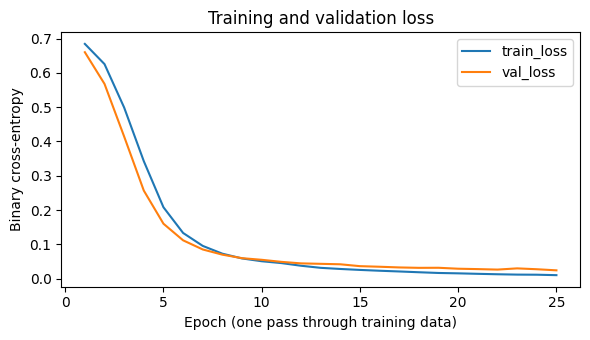

accuracy             0.99
balanced_accuracy    0.99
ROC_AUC              1.00
Name: Validation, dtype: float64

In [17]:
history = fit_binary(model, loader(x_train, y_train, batch_size=64, shuffle=True),
                     loader(x_val, y_val, batch_size=64), epochs=25, lr=0.01)
plot_history(history)
display(pd.Series(binary_scores(y_val, probabilities(model, x_val)), name="Validation"))

*Assignment: How much sequence does a filter see?*

Train a second model with kernel size 3. Compare with width 6 on validation. Can a single width-3 filter directly recognize all six bases of the motif?

In [18]:
seed_everything(42)
alternative = MotifCNN(kernel_size=6)  # Change to 3.
alternative_history = fit_binary(alternative, loader(x_train, y_train, batch_size=64, shuffle=True),
                                 loader(x_val, y_val, batch_size=64), epochs=25, lr=0.01)
display(pd.Series(binary_scores(y_val, probabilities(alternative, x_val)), name="Alternative validation"))

accuracy             0.99
balanced_accuracy    0.99
ROC_AUC              1.00
Name: Alternative validation, dtype: float64

*Write your answer here.*

### 3.7.5 Compare against a sequence baseline
The motif is A/T-rich, so even base composition could carry some information. A useful baseline is logistic regression on four base fractions. This ignores sequence order and gives us a fair question: does the CNN learn beyond composition?

Choose the CNN using validation loss. The baseline has a fixed configuration. Now evaluate the two methods once on the same test sequences.

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
baseline = make_pipeline(StandardScaler(), LogisticRegression(C=1.0, max_iter=1000, random_state=42))
baseline.fit(x_train.mean(axis=2), y_train)
chosen_cnn = model if history.val_loss.min() <= alternative_history.val_loss.min() else alternative
x_test = one_hot_dna(test_sequences)
results = {
    "Base-composition baseline": binary_scores(y_test, baseline.predict_proba(x_test.mean(axis=2))[:, 1]),
    "Selected CNN": binary_scores(y_test, probabilities(chosen_cnn, x_test)),
}
display(pd.DataFrame(results).T)

,accuracy,balanced_accuracy,ROC_AUC
Base-composition baseline,0.690,0.690,0.7461
Selected CNN,0.995,0.995,1.0000


*Assignment: What did we actually learn?*

Would strong performance prove that this CNN predicts promoter activity? Name two ways a real biological dataset differs from this generator.

*Write your answer here.*

*Optional assignment: Translation and lost information*

Why does max pooling help when the motif moves, and what task would it make harder? How would you change the model for counting motifs?

*Write your answer here.*